# Block-tridiagonal operators — precision form for Markov / state-space GPs

A block-tridiagonal matrix has non-zero blocks only on its main diagonal and the two adjacent diagonals; everywhere else is zero. This is the **precision form** of any Markov chain — Kalman filters, hidden Markov models, AR processes, discretized linear SDEs all live here. Storage is $O(Nd^2)$ instead of $O((Nd)^2)$, and every primitive (`cholesky`, `solve`, `logdet`, `diag`) drops from $O((Nd)^3)$ to $O(Nd^3)$ via a banded forward-backward sweep.

This is the *temporal-Markov dual* of Toeplitz: where Toeplitz exploits **stationarity** (constant diagonals, dense in covariance form), block-tridiagonal exploits **conditional independence** (banded sparsity in precision form). Many state-space GP workflows convert from one to the other deliberately — covariance form is dense but stationary, precision form is sparse but Markov, and the right choice depends on which primitive dominates your cost.

## 0. Where block-tridiagonal precision shows up in geoscience

A non-exhaustive list — every one of these is an operator-typed `BlockTriDiag` in `gaussx`:

- **Kalman filtering / smoothing on geophysical timeseries**: trajectory estimation for GPS displacements, sea-level reconstruction, gravimeter records, magnetometer drift correction. The full smoothed posterior precision over all $N$ time-steps is *exactly* block-tridiagonal — the Markov property means past and future are conditionally independent given the present, which forces the precision into this banded form.
- **State-space GP regression**: every Matérn kernel of half-integer order has a finite-dimensional state-space representation; on a regular time grid the resulting joint precision is block-tridiagonal with block size = state dimension (1 for Matérn-1/2, 2 for 3/2, 3 for 5/2). Hartikainen & Särkkä (2010) gave the systematic recipe; this is what makes Matérn GPs scale to billions of points in temporal seismology, climate reconstructions, and remote-sensing time series.
- **Discretized linear SDEs / OU processes**: the Ornstein–Uhlenbeck precision on a regular grid is exactly block-tridiagonal with $1\times 1$ blocks — the diagonal is $(1+\phi^2)/\sigma^2$, the sub-diagonal is $-\phi/\sigma^2$.
- **1-D GMRF priors for inverse problems**: the second-difference precision on a regular grid (encoding a smoothness prior for inversions, e.g. seismic-velocity profiles or ice-thickness estimation) is tridiagonal with blocks of size 1.
- **Spacetime separable models**: when one axis is Markov and the other is general (e.g. Markov in time × dense in space), the precision factorizes as `Kronecker(BlockTriDiag, K_space)` — used heavily in animal-movement modelling, ENSO state-space filters, and ocean-data assimilation.
- **Filtering with non-Gaussian likelihoods (Newton / Laplace approximations)**: each Newton step against a state-space prior produces a block-tridiagonal posterior precision (prior + diagonal Hessian sites = block-tridiagonal sum). Used in extended Kalman smoothing, log-Gaussian Cox processes for earthquake catalogs, Bayesian filtering of gridded environmental observations.

The mental shortcut: **if your process is Markov in one of its dimensions, the precision is block-tridiagonal in that dimension**. Banded sparsity is the language of conditional independence.

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import (
    BlockTriDiag,
    LowerBlockTriDiag,
    cholesky,
    logdet,
    solve,
)

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})

## 1. The block-tridiagonal precision

A symmetric block-tridiagonal precision matrix $\Lambda \in \mathbb{R}^{Nd \times Nd}$ is parameterized by $N$ diagonal blocks $D_k\in\mathbb{R}^{d\times d}$ and $N-1$ sub-diagonal blocks $A_k\in\mathbb{R}^{d\times d}$:

```{math}
:label: eq:btd-def
\Lambda = \begin{bmatrix}
D_1 & A_1^\top & & & \\
A_1 & D_2 & A_2^\top & & \\
    & A_2 & D_3 & \ddots & \\
    &     & \ddots & \ddots & A_{N-1}^\top \\
    &     &        & A_{N-1} & D_N
\end{bmatrix}
```

Storage: $N$ blocks of size $d\times d$ on the diagonal plus $N-1$ off-diagonal blocks. Total: $(2N-1)d^2$ floats — *linear* in $N$ instead of quadratic.

The shape encodes the Markov assumption: $\Lambda_{ij} = 0$ whenever $|i-j| > 1$ in block coordinates means $\mathrm{Cov}(x_i, x_j \mid \text{rest}) = 0$ for non-adjacent blocks — past and future are conditionally independent given the present.

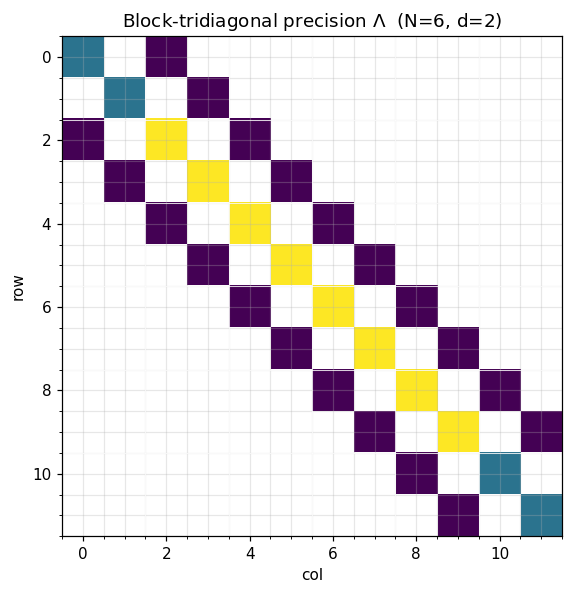

size           : 12 x 12
storage (BTD)  : 44 floats
storage (dense): 144 floats   (3x more)


In [2]:
# A small AR(1)-like precision with d=2 latent state per timestep
N, d = 6, 2
phi, sigma2 = 0.7, 1.0

# Identity-block AR(1) precision: D_k = (1 + ϕ²)/σ² · I,  A_k = -ϕ/σ² · I
D_blocks = jnp.tile(((1.0 + phi**2) / sigma2) * jnp.eye(d), (N, 1, 1))
A_blocks = jnp.tile((-phi / sigma2) * jnp.eye(d), (N - 1, 1, 1))
# Boundary: marginal-stationary endpoints
D_blocks = D_blocks.at[0].set((1.0 / sigma2) * jnp.eye(d))
D_blocks = D_blocks.at[-1].set((1.0 / sigma2) * jnp.eye(d))

Lam = BlockTriDiag(D_blocks, A_blocks, tags=lx.positive_semidefinite_tag)

# Visualize the sparsity pattern
fig, ax = plt.subplots(figsize=(5.5, 5.5))
M = Lam.as_matrix()
ax.imshow(jnp.where(jnp.abs(M) > 1e-12, jnp.abs(M), jnp.nan),
          cmap="viridis", aspect="equal")
for k in range(1, N):
    ax.axhline(k * d - 0.5, color="white", lw=0.5)
    ax.axvline(k * d - 0.5, color="white", lw=0.5)
ax.set_title(rf"Block-tridiagonal precision $\Lambda$  (N={N}, d={d})")
ax.set_xlabel("col"); ax.set_ylabel("row")
plt.tight_layout()
plt.show()

print(f"size           : {Lam._size} x {Lam._size}")
print(f"storage (BTD)  : {(2*N - 1) * d * d} floats")
print(f"storage (dense): {Lam._size**2} floats   ({Lam._size**2 / ((2*N - 1)*d*d):.0f}x more)")

## 2. Banded matvec & Cholesky in $O(Nd^3)$

The matvec sweeps once through the blocks:

```{math}
:label: eq:btd-mv
(\Lambda x)_k = D_k x_k + A_{k-1} x_{k-1} + A_k^\top x_{k+1}
```

— three block-matvecs per row, total $O(Nd^2)$.

The Cholesky factor of a symmetric positive-definite block-tridiagonal matrix is *lower block-bidiagonal* — same banded shape, just lower-triangular. `gaussx.cholesky(BlockTriDiag)` returns a `LowerBlockTriDiag` and runs the banded Cholesky sweep in $O(Nd^3)$ flops:

```{math}
:label: eq:btd-chol
\Lambda = L L^\top, \qquad L = \begin{bmatrix} L_1 & & \\ M_1 & L_2 & \\ & \ddots & \ddots \end{bmatrix}, \qquad L_k L_k^\top = D_k - M_{k-1}M_{k-1}^\top
```

This is *exactly* the Kalman filter forward sweep written in matrix language. Once $L$ is in hand, every downstream primitive (`solve`, `logdet`, sampling) is one or two banded back-substitutions, also $O(Nd^3)$.

In [3]:
# Verify matvec
v = jax.random.normal(jax.random.PRNGKey(1), (N * d,))
ref = M @ v
print(f"matvec error : {jnp.linalg.norm(Lam.mv(v) - ref):.2e}")

# Cholesky lands in the banded factor type
L_op = cholesky(Lam)
print(f"\ncholesky type    : {type(L_op).__name__}")
print(f"factor matches L : {jnp.allclose(L_op.as_matrix() @ L_op.as_matrix().T, M, atol=1e-10)}")

# Solve via banded forward-backward sweep
b = jnp.ones(N * d)
x_struct = solve(Lam, b)
x_dense  = jnp.linalg.solve(M, b)
print(f"solve error      : {jnp.linalg.norm(x_struct - x_dense):.2e}")

# logdet via 2 sum log diag(L)
ld_struct = float(logdet(Lam))
ld_dense  = float(jnp.linalg.slogdet(M)[1])
print(f"logdet (struct)  : {ld_struct:.6f}")
print(f"logdet (dense)   : {ld_dense:.6f}")

matvec error : 1.11e-16



cholesky type    : LowerBlockTriDiag
factor matches L : True


solve error      : 1.26e-15


logdet (struct)  : -1.346689
logdet (dense)   : -1.346689


## 3. Cost table — banded vs dense

With $N$ blocks of size $d\times d$ (total dimension $n = Nd$):

| Operation | Dense | BlockTriDiag |
|---|---|---|
| Storage | $n^2 = N^2 d^2$ | $(2N-1)d^2$ |
| Matvec | $O(n^2)$ | $O(Nd^2)$ |
| Cholesky | $O(n^3) = O(N^3 d^3)$ | $O(Nd^3)$ |
| Solve (after Cholesky) | $O(n^2)$ | $O(Nd^2)$ |
| logdet | $O(n^3)$ | $O(Nd^3)$ |
| Sample $x\sim\mathcal{N}(0,\Lambda^{-1})$ | $O(n^3)$ | $O(Nd^3)$ |

*Linear in $N$* across the board — the asymptotic gap from $O(N^3)$ to $O(N)$ is what makes million-step state-space GP regression tractable. For Matérn-3/2 in time, $d=2$ and $N$ can be $10^7$ on a single GPU; the dense form is unimaginable at that scale.

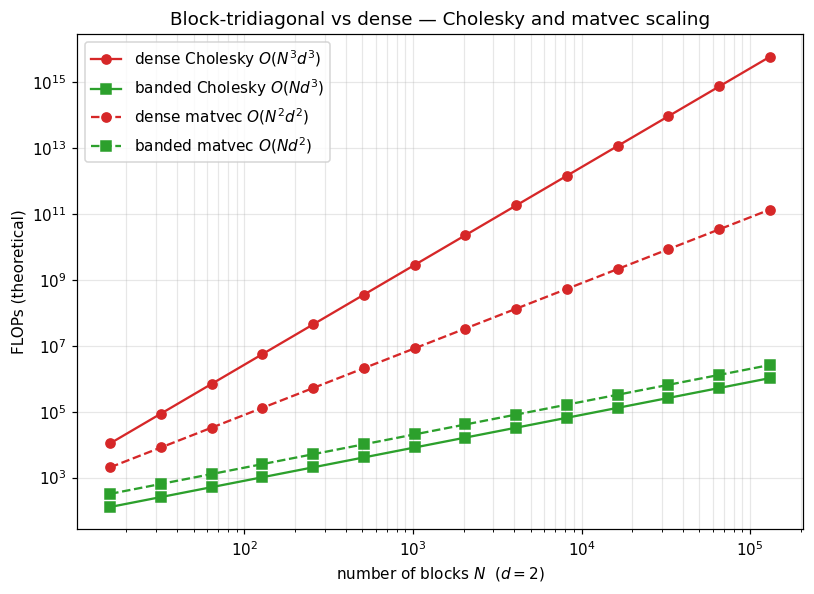

In [4]:
# Theoretical FLOP plot: dense vs banded Cholesky as N grows
Ns = np.array([2**k for k in range(4, 18)])  # 16 .. 130k
d = 2
dense_chol  = (1/3) * (Ns * d)**3
banded_chol = Ns * d**3
dense_mv    = 2 * (Ns * d)**2
banded_mv   = 5 * Ns * d**2

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.loglog(Ns, dense_chol,  "C3-",  marker="o", label=r"dense Cholesky $O(N^3 d^3)$")
ax.loglog(Ns, banded_chol, "C2-",  marker="s", label=r"banded Cholesky $O(N d^3)$")
ax.loglog(Ns, dense_mv,    "C3--", marker="o", label=r"dense matvec $O(N^2 d^2)$")
ax.loglog(Ns, banded_mv,   "C2--", marker="s", label=r"banded matvec $O(N d^2)$")
ax.set_xlabel(r"number of blocks $N$  ($d=2$)")
ax.set_ylabel("FLOPs (theoretical)")
ax.set_title("Block-tridiagonal vs dense — Cholesky and matvec scaling")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 4. Sampling and conditional smoothing

Drawing $x\sim\mathcal{N}(0, \Lambda^{-1})$ from a precision-form Gaussian uses the Cholesky factor $\Lambda = LL^\top$ via $x = L^{-\top} z$ with $z\sim\mathcal{N}(0, I)$ — a *backward* triangular solve through the banded factor, $O(Nd^3)$ total.

In Kalman-smoother language:

- **Forward sweep** = Cholesky of $\Lambda$ (the prediction + update steps).
- **Backward sweep** = $L^{-\top}$ solve (the RTS / two-filter smoothing pass).

The two sweeps over the banded factor *are* the smoothing algorithm written in matrix-vector primitives. Everything that's commonly written as filter recursions is already there in `solve(BlockTriDiag, …)`.

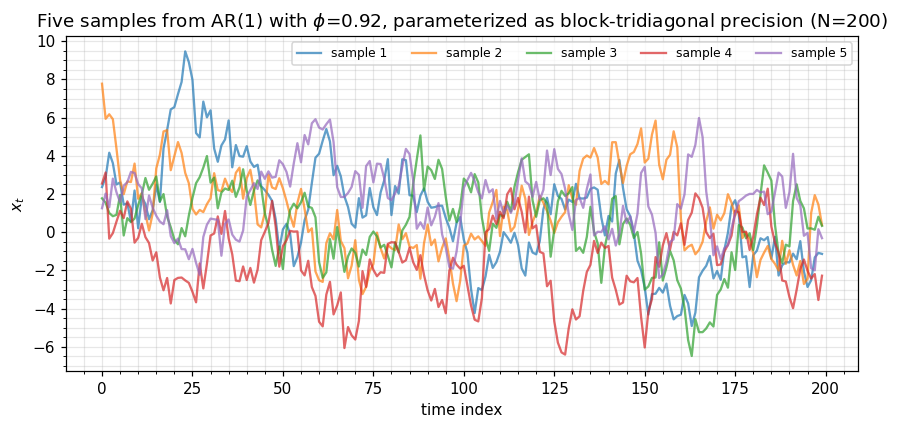

In [5]:
# Build a longer chain and sample from N(0, Λ⁻¹) using the banded Cholesky
N_long, d = 200, 1
phi, sigma2 = 0.92, 1.0
D_long = jnp.tile(((1.0 + phi**2) / sigma2) * jnp.eye(d), (N_long, 1, 1))
A_long = jnp.tile((-phi / sigma2) * jnp.eye(d), (N_long - 1, 1, 1))
D_long = D_long.at[0].set((1.0 / sigma2) * jnp.eye(d))
D_long = D_long.at[-1].set((1.0 / sigma2) * jnp.eye(d))
Lam_long = BlockTriDiag(D_long, A_long, tags=lx.positive_semidefinite_tag)
L_long = cholesky(Lam_long)

# Sample by solving L^T x = z  (precision-form sampling)
keys = jax.random.split(jax.random.PRNGKey(2), 5)
samples = []
for k in keys:
    z = jax.random.normal(k, (N_long * d,))
    # x = L^{-T} z  via a triangular solve on the lower-bidiagonal factor
    x = jax.scipy.linalg.solve_triangular(L_long.as_matrix().T, z, lower=False)
    samples.append(np.asarray(x).flatten())

fig, ax = plt.subplots(figsize=(8, 4))
for i, s in enumerate(samples):
    ax.plot(s, alpha=0.7, label=f"sample {i+1}")
ax.set_xlabel("time index")
ax.set_ylabel("$x_t$")
ax.set_title(rf"Five samples from AR(1) with $\phi$={phi}, parameterized as block-tridiagonal precision (N={N_long})")
ax.legend(loc="upper right", fontsize=8, ncol=5)
plt.tight_layout()
plt.show()

## 5. Prior + diagonal likelihood = block-tridiagonal posterior

The shape is *closed* under adding diagonal precision (Gaussian likelihood / Newton sites). If $\Lambda_{\mathrm{prior}}$ is block-tridiagonal and $W$ is block-diagonal (one Hessian block per timestep, e.g. from a Gaussian observation model), then

```{math}
:label: eq:btd-posterior
\Lambda_{\mathrm{post}} = \Lambda_{\mathrm{prior}} + W
```

is *also* block-tridiagonal — `gaussx.BlockTriDiag` exposes `__add__` / `__sub__` / `__mul__` so you can write this directly without leaving the structured class. This is exactly the Newton step against a state-space prior that powers extended-Kalman smoothing, IPP filtering for Cox processes, and the Bayesian-filtering literature for non-conjugate observation models.

In [6]:
# Posterior precision = prior + diagonal likelihood
# Likelihood: Gaussian observations with per-timestep precision w_k
W_blocks = jnp.tile(2.0 * jnp.eye(d), (N_long, 1, 1))   # 1/σ²_obs = 2.0
A_zero = jnp.zeros_like(A_long)
W_op = BlockTriDiag(W_blocks, A_zero)

Lam_post = Lam_long + W_op
print(f"posterior type     : {type(Lam_post).__name__}")
print(f"posterior is BTD   : {isinstance(Lam_post, BlockTriDiag)}")
print(f"posterior shape    : {Lam_post._size}")

# The added structure is preserved — same banded primitives still apply.
ld_post = float(logdet(BlockTriDiag(Lam_post.diagonal, Lam_post.sub_diagonal,
                                    tags=lx.positive_semidefinite_tag)))
print(f"posterior logdet   : {ld_post:.4f}")

posterior type     : BlockTriDiag
posterior is BTD   : True
posterior shape    : 200


posterior logdet   : 256.3895


## 6. The covariance ↔ precision duality

Two ways to encode the same Markov GP:

| Form | Storage | Dense in | Sparse in | Cheap primitive |
|---|---|---|---|---|
| Covariance $K$ | dense (Toeplitz if stationary) | covariance | nothing | matvec via FFT (Toeplitz) |
| Precision $\Lambda = K^{-1}$ | block-tridiagonal | precision | $|i-j|>1$ blocks | Cholesky, solve, logdet $O(Nd^3)$ |

Choose by what the workload needs:

- **Filtering / smoothing / sampling / likelihood evaluation** → precision form, `BlockTriDiag`.
- **Pure prediction at new timepoints from a stationary kernel** → covariance form, `Toeplitz`.
- **Both** → keep both; convert as needed. `gaussx`'s state-space primitives handle the conversion when you need it.

The next notebook (1.6 `MaskedOperator`) covers the missing-data variant of this story: when observations are sampled at a subset of grid points, you wrap a Toeplitz or BlockTriDiag operator in a mask that picks out the observed indices, preserving structure on the prior side while correctly accounting for the holes in the data.